## Mesoscale Kinetic Energy, Eddy Kinetic Energy, Strain

In [2]:
from smode_import import *

In [3]:
# some functions....
def distance(lon1, lat1, lon2, lat2):
    from math import radians, cos, sin, sqrt, atan2
    R = 6371000 # Earth radius in meters
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    distance = R * c
    return distance

def coriolis_parameter(latitude):
    omega = 7.2921e-5  # Angular velocity of the Earth (radians per second)
    phi = np.radians(latitude)  # Convert latitude to radians
    f = 2 * omega * np.sin(phi)  # Calculate the Coriolis parameter
    return f

## Geostrophic Strain & Kinetic Energy

In [10]:
# From Zhang et al., 2022

# Load Mesoscale Field
folder='/Users/elise/data/'
ncfile='cmems_obs-sl_glo_phy-ssh_my_allsat-l4-duacs-0.25deg_P1D_1715024829743.nc'
geos  = xr.open_dataset(folder+ncfile)
geos  = geos.sel(latitude=slice(30,40),longitude=slice(-129,-120)) # take a subset

In [11]:
# Geostrophic velocities
def kinematics(geos):
    ug, vg = geos.ugos, geos.vgos
    lon,lat= geos.longitude, geos.latitude
    grid_lon,grid_lat = np.meshgrid(geos.longitude,geos.latitude)
    
    # Calculate distances from the reference point
    x = np.array([distance(lon[0], lat[0], lon_val, lat[0]) for lon_val in lon])
    y = np.array([distance(lon[0], lat[0], lon[0], lat_val) for lat_val in lat])
    x_grid, y_grid = np.meshgrid(x,y)
    
    # compute divergence
    dx = np.gradient(x_grid,axis=1)
    dy = np.gradient(y_grid,axis=0)
    
    dudx = np.gradient(ug,axis=1) / dx
    dudy = np.gradient(ug,axis=0) / dy
    dvdx = np.gradient(vg,axis=1) / dx
    dvdy = np.gradient(vg,axis=0) / dy
    
    # Compute kinematics variables
    f = np.mean(coriolis_parameter(lat.values))              # coriolis parameter
    Delta_g = dudx - dvdy                                    # divergence
    Zeta_g  = dvdx - dudy                                    # relative vorticity
    Sg      = np.sqrt( (dudx - dvdy)**2 + (dvdx + dudy)**2 ) # strain
    Eg      = 0.5 * (ug.values**2 + vg.values**2)            # kinetic energy

    # eddy kinetic energy
    u,v = geos.ugos, geos.vgos
    u_p = u - u.mean(dim='time')
    v_p = v - v.mean(dim='time')
    eke = (u_p**2 + v_p**2) / 2

    
    # Wrap into xarray DataArray
    kinematics = xr.Dataset({
            'divergence_g': (('time', 'lat', 'lon'), Delta_g),
            'vorticity_g': (('time', 'lat', 'lon'), Zeta_g),
            'Sg': (('time', 'lat', 'lon'), Sg),
            'Eg': (('time', 'lat', 'lon'), Eg),
            'EKE': (('time','lat','lon' ), eke.values),
            'f': f
        }, coords={
            'time': geos.time,
            'lat': lat.values,
            'lon': lon.values
        })
    return kinematics
#kinematics.to_netcdf('geostrophic_kinematics.nc')

In [12]:
# increase spatial resolution
def increase_resolution(geos,N):
    from scipy.interpolate import griddata
    lon,lat = geos.longitude.values, geos.latitude.values
    grid_lon,grid_lat = np.meshgrid(lon,lat)
    
    # Define new longitude and latitude arrays with increased resolution
    new_x = np.linspace(lon[0], lon[-1], len(lon) * N)
    new_y = np.linspace(lat[0], lat[-1], len(lat) * N)
    
    # Create meshgrid for new longitudes and latitudes
    grid_x, grid_y = np.meshgrid(new_x, new_y)
    
    T = geos.dims['time']
    I,J = grid_x.shape
    
    grid_u = np.empty([T,I,J])
    grid_v = np.empty([T,I,J])
    
    for i in range(T):
        # Interpolate data to the new grid
        grid_u[i,...] = griddata((grid_lon.flatten(), grid_lat.flatten()), 
                           geos.ugos.isel(time=i).values.flatten(), 
                             (grid_x, grid_y), method='linear')
    
        grid_v[i,...] = griddata((grid_lon.flatten(), grid_lat.flatten()),
                           geos.vgos.isel(time=i).values.flatten(), 
                             (grid_x, grid_y), method='linear')
        
    
    # Wrap into xarray DataArray
    new_ds = xr.Dataset({
            'ugos': (('time', 'latitude', 'longitude'), grid_u),
            'vgos': (('time', 'latitude', 'longitude'), grid_v),
        }, coords={
            'time': geos.time,
            'latitude': new_y,
            'longitude': new_x
        })
    
    return new_ds

In [103]:
# Increase resolution
N = 8  # Increase resolution by a factor of N
#geos_mon = geos.resample(time='MS').mean('time')
geos_sub = geos.sel(time=slice('2023-04','2023-06'))
ds = increase_resolution(geos_sub,N=N)
kins = kinematics(ds)
kins

<xarray.Dataset>
Dimensions:       (time: 68, lat: 256, lon: 288)
Coordinates:
  * time          (time) datetime64[ns] 2023-04-01 2023-04-02 ... 2023-06-07
  * lat           (lat) float64 32.12 32.16 32.19 32.22 ... 39.81 39.84 39.88
  * lon           (lon) float64 -128.9 -128.8 -128.8 ... -120.2 -120.2 -120.1
Data variables:
    divergence_g  (time, lat, lon) float64 -3.919e-06 -3.056e-06 ... nan nan
    vorticity_g   (time, lat, lon) float64 4.434e-06 4.412e-06 ... nan nan
    Sg            (time, lat, lon) float64 3.926e-06 3.067e-06 ... nan nan
    Eg            (time, lat, lon) float64 0.012 0.01124 0.01053 ... nan nan nan
    EKE           (time, lat, lon) float64 0.01803 0.01727 0.01656 ... nan nan
    f             float64 8.566e-05

/var/folders/vw/s5yfsczj0nzgw4mcs35y8c9r0000gp/T/ipykernel_4123/3507368367.py:5: DeprecationWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in g.axes.flat: coastline(ax)


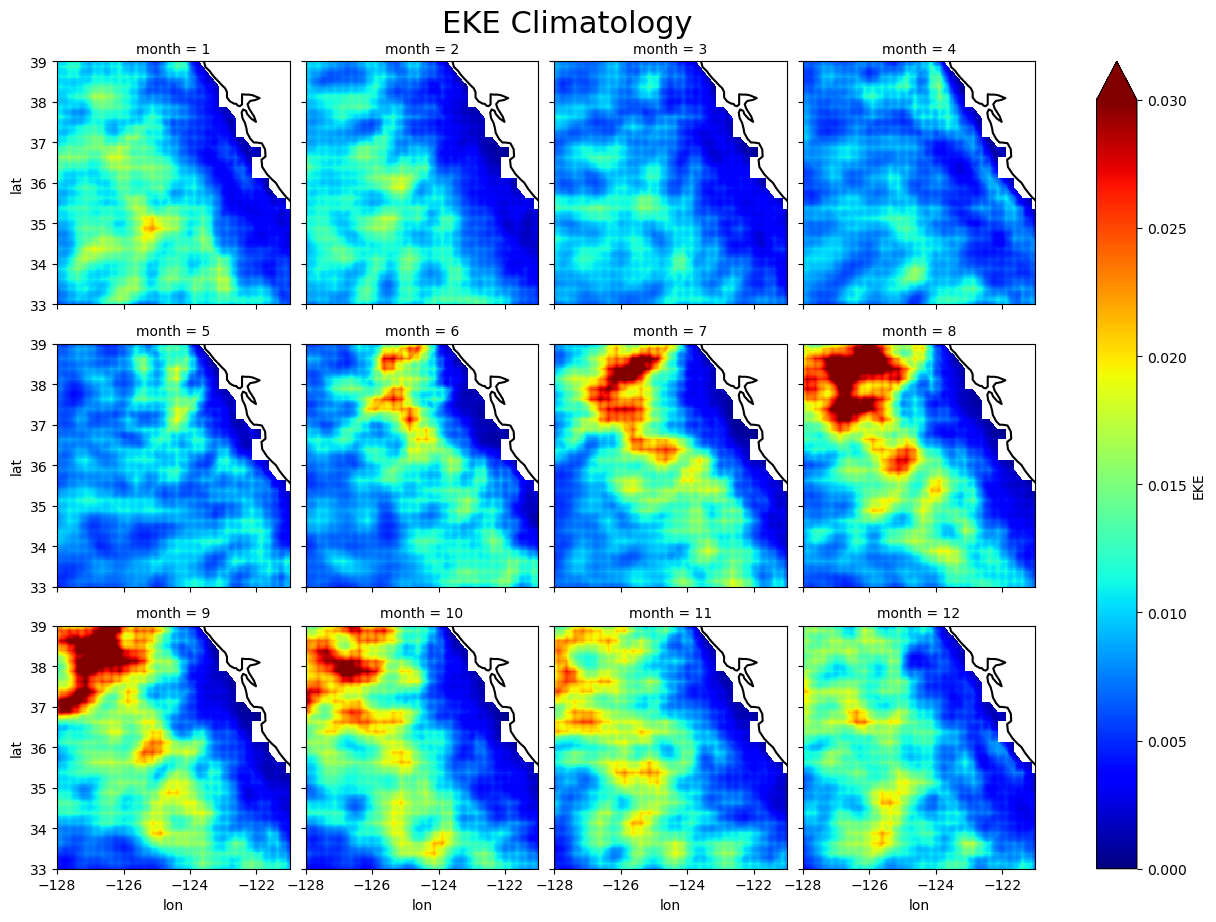

In [56]:
#kins.EKE.isel(time=-1).plot(vmin=0,vmax=0.05)

monthly_clim = kins.EKE.groupby('time.month').mean(dim='time')
g = monthly_clim.plot.pcolormesh(col='month', col_wrap=4, cmap='jet', vmin=0, vmax=0.03)
for ax in g.axes.flat: coastline(ax)
plt.suptitle('EKE Climatology',x=0.44,y=1.02,fontsize=22);

In [157]:
geos0=geos.resample(time='M').mean()
geos0

ds0=increase_resolution(geos0,N=4)

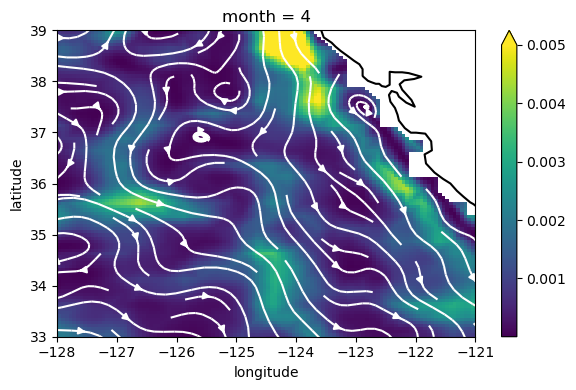

In [172]:
fig,ax=plt.subplots(1,1,figsize=(6,4))
ds1=ds0.groupby('time.month').mean().isel(month=4-1)

ek=0.5*(ds1.vgos**2 + ds1.ugos**2)
ek.plot(ax=ax,vmax=0.005)

lons,lats=np.meshgrid(ds1.longitude.values,ds1.latitude.values)
ax.streamplot(lons,lats,
                  ds1.ugos,
                  ds1.vgos,
                  color='w')
coastline(ax)
plt.tight_layout();

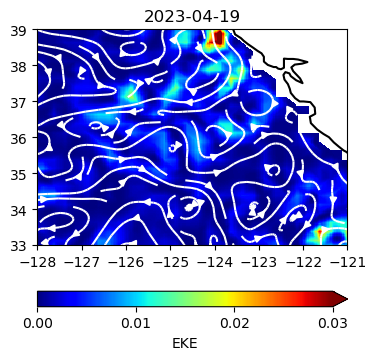

In [115]:
time='2023-04-19'
plt.figure(figsize=(4,4))
kins.EKE.sel(time=time).plot(cmap='jet', vmin=0, vmax=0.03,
                                  cbar_kwargs={'ticks': [0,0.01,0.02,0.03],
                                               'spacing': 'proportional',
                                                'label':'EKE',
                                                'orientation': 'horizontal'})
lons,lats=np.meshgrid(geos_sub.longitude.values,geos_sub.latitude.values)
plt.streamplot(lons,lats,
               geos_sub.ugos.sel(time=time),
               geos_sub.vgos.sel(time=time),
              color='w')
plt.xlabel(''); plt.ylabel('')
plt.title(time)
coastline(plt.gca())

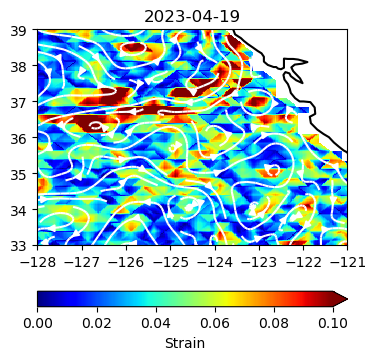

In [127]:
time='2023-04-19'
f=kins.f.values
plt.figure(figsize=(4,4))
(kins.Sg/f).sel(time=time).plot(cmap='jet', vmin=0,vmax=0.1,
                                  cbar_kwargs={
                                               'spacing': 'proportional',
                                                'label':'Strain',
                                                'orientation': 'horizontal'})
lons,lats=np.meshgrid(geos_sub.longitude.values,geos_sub.latitude.values)
plt.streamplot(lons,lats,
               geos_sub.ugos.sel(time=time),
               geos_sub.vgos.sel(time=time),
              color='w')
plt.xlabel(''); plt.ylabel('')
plt.title(time)
coastline(plt.gca())

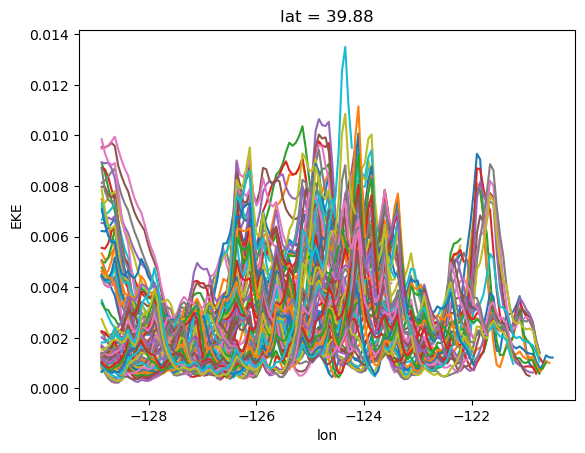

In [96]:
EKE=kins.EKE.mean(dim='time')
for ilat in range(160):
    idx=np.where(np.isnan(EKE.isel(lat=ilat)))[0]
    if len(idx)>1:
        EKE.isel(lat=ilat,lon=slice(0,idx[0]-1)).plot()

# Animation

In [139]:
import matplotlib.animation as animation
import os
from IPython.display import Video

# Function to create a plot for a single frame
def create_plot(it):
    data=aviso.isel(time=it)
    time=data.time
    
    fig,ax=plt.subplots(1,1)
    ax.contourf(lons,lats,data.sla,np.linspace(-0.1,0.1,50),cmap='rainbow',extend='both')
    ax.streamplot(lons,lats,data.ugos,data.vgos,
                   color='k',density=4,)
                   #broken_streamlines=False)
    
    yyyy=time.dt.year.values
    mm=time.dt.month.values
    dd=time.dt.day.values
    ax.set_xlim(-127,-120)
    ax.set_ylim(34,39)
    ax.set_title(f'{yyyy}-{mm:02d}-{dd:02d}')
    #plt.show()
    plt.close(fig)  # Close the figure to prevent displaying it
    return fig

# Create a directory to store the plots
if not os.path.exists('plots'):
    os.makedirs('plots')

# Create plots for each frame and save as PNG files
lons,lats=np.meshgrid(aviso.longitude,aviso.latitude)
num_frames=aviso.dims['time']
for it in range(num_frames):
    fig = create_plot(it)
    fig.savefig(f'plots/frame_{it:03d}.png')

# Create a list of image filenames
image_files = [f'plots/frame_{i:03d}.png' for i in range(num_frames)]

In [140]:
# Create a movie from the images using FFMpeg
output_movie_file = 'output_movie.mp4'
command = f'ffmpeg -r 5 -i plots/frame_%03d.png -vf "fps=25,format=yuv420p" {output_movie_file}'
os.system(command)

# Cleanup: Remove the temporary plot files
#for file in image_files:
#    os.remove(file)

print(f'Movie created: {output_movie_file}')

Video(output_movie_file)

ffmpeg version 6.1.1 Copyright (c) 2000-2023 the FFmpeg developers
  built with Apple clang version 15.0.0 (clang-1500.1.0.2.5)
  configuration: --prefix=/opt/homebrew/Cellar/ffmpeg/6.1.1_4 --enable-shared --enable-pthreads --enable-version3 --cc=clang --host-cflags= --host-ldflags='-Wl,-ld_classic' --enable-ffplay --enable-gnutls --enable-gpl --enable-libaom --enable-libaribb24 --enable-libbluray --enable-libdav1d --enable-libharfbuzz --enable-libjxl --enable-libmp3lame --enable-libopus --enable-librav1e --enable-librist --enable-librubberband --enable-libsnappy --enable-libsrt --enable-libssh --enable-libsvtav1 --enable-libtesseract --enable-libtheora --enable-libvidstab --enable-libvmaf --enable-libvorbis --enable-libvpx --enable-libwebp --enable-libx264 --enable-libx265 --enable-libxml2 --enable-libxvid --enable-lzma --enable-libfontconfig --enable-libfreetype --enable-frei0r --enable-libass --enable-libopencore-amrnb --enable-libopencore-amrwb --enable-libopenjpeg --enable-libopen

Movie created: output_movie.mp4


[out#0/mp4 @ 0x60000205c600] video:1731kB audio:0kB subtitle:0kB other streams:0kB global headers:0kB muxing overhead: 0.307879%
frame=  380 fps=0.0 q=-1.0 Lsize=    1736kB time=00:00:15.08 bitrate= 943.0kbits/s speed=34.3x    
[libx264 @ 0x150005460] frame I:2     Avg QP:18.78  size: 45883
[libx264 @ 0x150005460] frame P:95    Avg QP:23.64  size: 17434
[libx264 @ 0x150005460] frame B:283   Avg QP:16.16  size:    83
[libx264 @ 0x150005460] consecutive B-frames:  0.5%  0.5%  0.0% 98.9%
[libx264 @ 0x150005460] mb I  I16..4: 34.3% 15.7% 50.0%
[libx264 @ 0x150005460] mb P  I16..4:  0.3%  0.6%  4.4%  P16..4:  4.3% 11.3% 17.2%  0.0%  0.0%    skip:62.0%
[libx264 @ 0x150005460] mb B  I16..4:  0.1%  0.0%  0.0%  B16..8:  4.9%  0.1%  0.0%  direct: 0.0%  skip:94.8%  L0:51.2% L1:48.4% BI: 0.4%
[libx264 @ 0x150005460] 8x8 transform intra:13.2% inter:16.2%
[libx264 @ 0x150005460] coded y,uvDC,uvAC intra: 64.3% 77.7% 76.5% inter: 5.8% 7.5% 5.8%
[libx264 @ 0x150005460] i16 v,h,dc,p: 60% 26% 12%  2%
[li

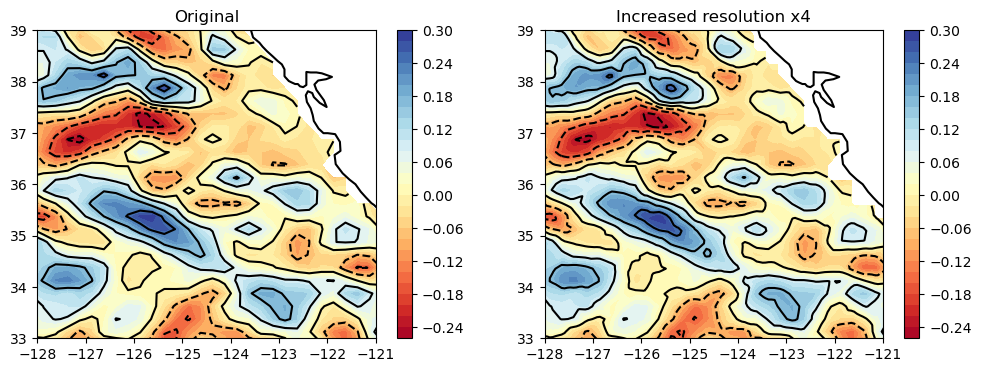

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(12,4))
p=ax[0].contourf(geos.longitude,geos.latitude,data,30,cmap='RdYlBu')
ax[0].contour(geos.longitude,geos.latitude,data,colors='k')
plt.colorbar(p,ax=ax[0])
ax[0].set_title('Original')
p=ax[1].contourf(new_lon,new_lat,increased_data,30,cmap='RdYlBu')
ax[1].contour(new_lon,new_lat,increased_data,colors='k')
plt.colorbar(p,ax=ax[1])
ax[1].set_title(f'Increased resolution x{N}');
for axis in ax: coastline(axis)